# Day 7 — Concrete Compressive Strength EDA

Dataset: `Concrete_Data.xls` (UCI Concrete Compressive Strength, 1030 rows, 9 columns).

**Target:** `compressive_strength` (MPa) — the strength of the concrete mix.

This notebook covers: shape / dtypes / missing values / `describe()`, the target distribution, a correlation heatmap, the 3 features most correlated with the target (with scatter plots), and a final check for skew, outliers, and non-random missingness.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# .xls requires the xlrd engine
df = pd.read_excel("Concrete_Data.xls")

# The original column names are long/inconsistent; rename to short, clean labels.
df.columns = [
    "cement",            # component 1 (kg/m^3)
    "blast_furnace_slag",# component 2 (kg/m^3)
    "fly_ash",           # component 3 (kg/m^3)
    "water",             # component 4 (kg/m^3)
    "superplasticizer",  # component 5 (kg/m^3)
    "coarse_aggregate",  # component 6 (kg/m^3)
    "fine_aggregate",    # component 7 (kg/m^3)
    "age",               # days
    "compressive_strength",  # TARGET (MPa)
]

TARGET = "compressive_strength"
df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
0,540.00,0.00,0.00,162.00,2.50,"1,040.00",676.00,28,79.99
1,540.00,0.00,0.00,162.00,2.50,"1,055.00",676.00,28,61.89
2,332.50,142.50,0.00,228.00,0.00,932.00,594.00,270,40.27
3,332.50,142.50,0.00,228.00,0.00,932.00,594.00,365,41.05
4,198.60,132.40,0.00,192.00,0.00,978.40,825.50,360,44.30


## 1. Shape, dtypes, missing values, describe()

In [2]:
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)

print("\nMissing values per column:")
missing = df.isna().sum()
print(missing)
print("\nTotal missing cells:", int(missing.sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Shape: (1030, 9)

Dtypes:
cement                  float64
blast_furnace_slag      float64
fly_ash                 float64
water                   float64
superplasticizer        float64
coarse_aggregate        float64
fine_aggregate          float64
age                       int64
compressive_strength    float64
dtype: object

Missing values per column:
cement                  0
blast_furnace_slag      0
fly_ash                 0
water                   0
superplasticizer        0
coarse_aggregate        0
fine_aggregate          0
age                     0
compressive_strength    0
dtype: int64

Total missing cells: 0
Duplicate rows: 25


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cement,"1,030.00",281.17,104.51,102.00,192.38,272.90,350.00,540.00
blast_furnace_slag,"1,030.00",73.90,86.28,0.00,0.00,22.00,142.95,359.40
fly_ash,"1,030.00",54.19,64.00,0.00,0.00,0.00,118.27,200.10
water,"1,030.00",181.57,21.36,121.75,164.90,185.00,192.00,247.00
superplasticizer,"1,030.00",6.20,5.97,0.00,0.00,6.35,10.16,32.20
coarse_aggregate,"1,030.00",972.92,77.75,801.00,932.00,968.00,"1,029.40","1,145.00"
fine_aggregate,"1,030.00",773.58,80.18,594.00,730.95,779.51,824.00,992.60
age,"1,030.00",45.66,63.17,1.00,7.00,28.00,56.00,365.00
compressive_strength,"1,030.00",35.82,16.71,2.33,23.71,34.44,46.14,82.60


## 2. Target distribution

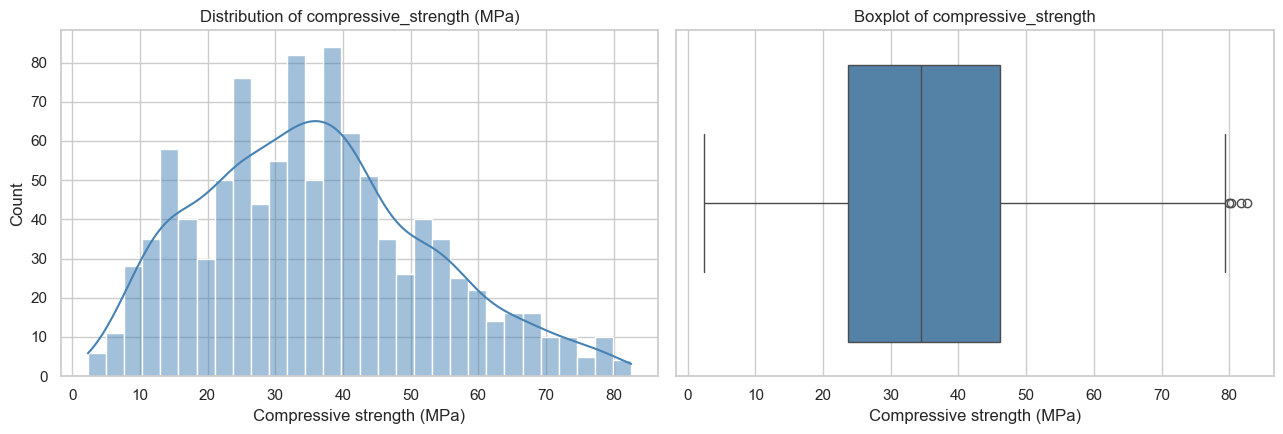

Skewness: 0.417
Kurtosis: -0.314
count   1,030.00
mean       35.82
std        16.71
min         2.33
25%        23.71
50%        34.44
75%        46.14
max        82.60
Name: compressive_strength, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df[TARGET], kde=True, bins=30, ax=axes[0], color="steelblue")
axes[0].set_title(f"Distribution of {TARGET} (MPa)")
axes[0].set_xlabel("Compressive strength (MPa)")

sns.boxplot(x=df[TARGET], ax=axes[1], color="steelblue")
axes[1].set_title(f"Boxplot of {TARGET}")
axes[1].set_xlabel("Compressive strength (MPa)")

plt.tight_layout()
plt.show()

print(f"Skewness: {df[TARGET].skew():.3f}")
print(f"Kurtosis: {df[TARGET].kurt():.3f}")
print(df[TARGET].describe())

## 3. Correlation heatmap

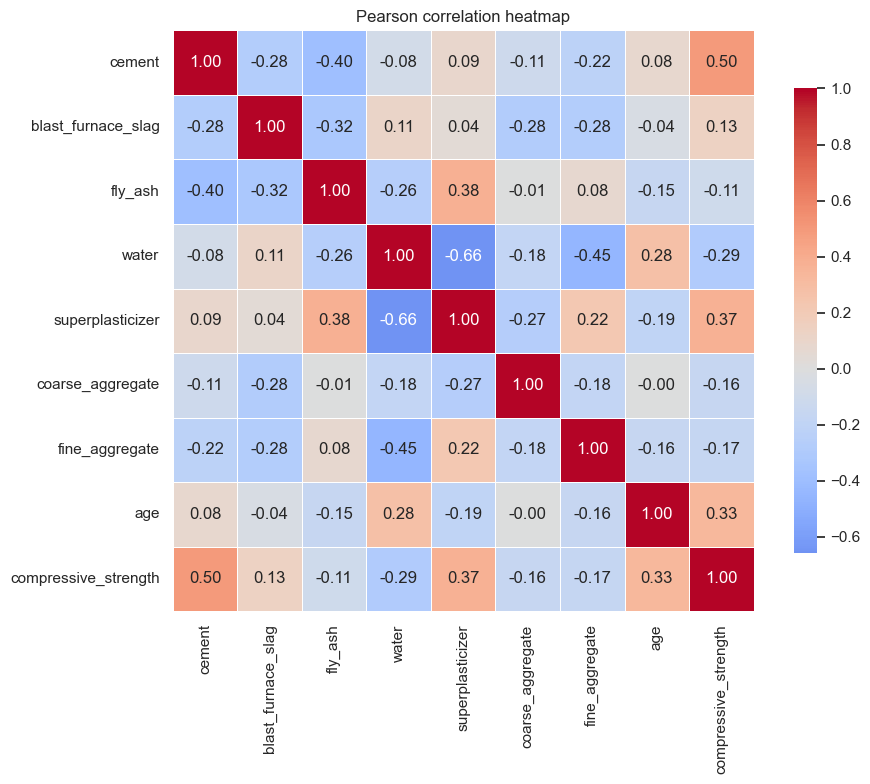

In [5]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
)
plt.title("Pearson correlation heatmap")
plt.tight_layout()
plt.show()

## 4. Top 3 features most correlated with the target

Features ranked by |correlation| with target:
cement                0.50
superplasticizer      0.37
age                   0.33
water                -0.29
fine_aggregate       -0.17
coarse_aggregate     -0.16
blast_furnace_slag    0.13
fly_ash              -0.11
Name: compressive_strength, dtype: float64

Top 3 features: ['cement', 'superplasticizer', 'age']


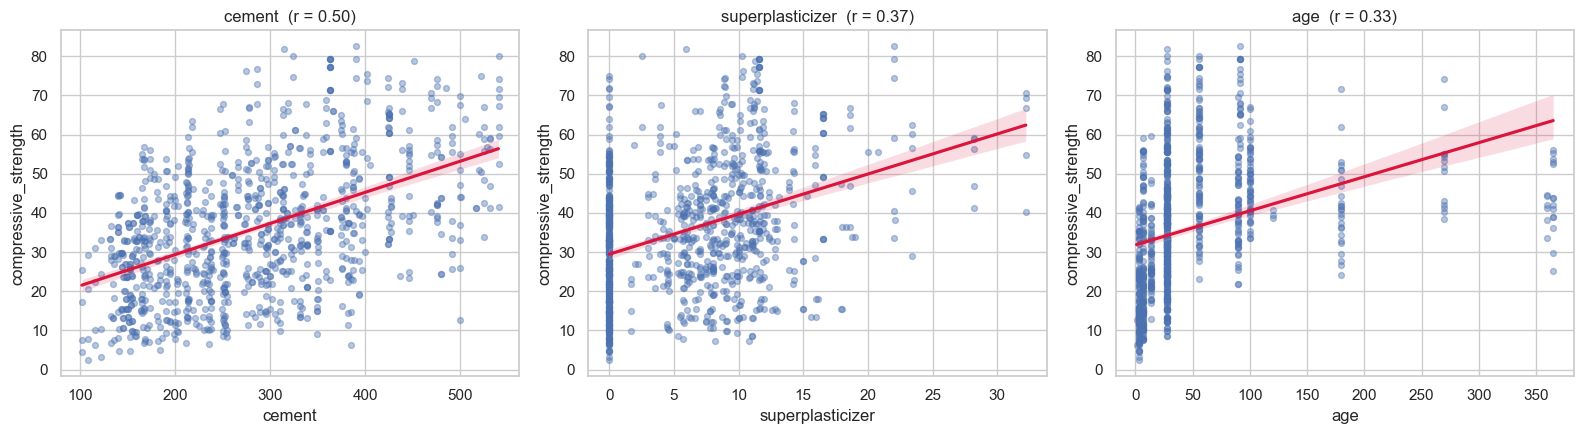

In [6]:
# Correlation of every feature with the target, ranked by absolute strength
target_corr = corr[TARGET].drop(TARGET)
ranked = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
print("Features ranked by |correlation| with target:")
print(ranked)

top3 = ranked.index[:3].tolist()
print("\nTop 3 features:", top3)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, feat in zip(axes, top3):
    sns.regplot(
        data=df, x=feat, y=TARGET, ax=ax,
        scatter_kws={"alpha": 0.4, "s": 18}, line_kws={"color": "crimson"},
    )
    ax.set_title(f"{feat}  (r = {target_corr[feat]:.2f})")

plt.tight_layout()
plt.show()

## 5. Data-quality flags: skew, outliers, non-random missingness

In [7]:
# --- Skew ---  (|skew| > 1 => strongly skewed, 0.5-1 => moderate)
skew = df.skew().sort_values(key=np.abs, ascending=False)
print("Skewness (|skew|>1 strong, 0.5-1 moderate):")
print(skew, "\n")

# --- Outliers ---  count via the 1.5*IQR rule per column
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lo) | (s > hi)
    return int(mask.sum()), round(100 * mask.mean(), 1)

print("Outliers per column (1.5*IQR rule):  count, % of rows")
out = pd.DataFrame(
    {c: iqr_outliers(df[c]) for c in df.columns},
    index=["n_outliers", "pct"],
).T.sort_values("n_outliers", ascending=False)
print(out, "\n")

# --- Missingness ---  none expected; report any structural zeros instead
print("Missing values per column:")
print(df.isna().sum().to_string())
print("\nRows that are exactly zero per column (structural 'absent ingredient', not NaN):")
print((df == 0).sum().to_string())

Skewness (|skew|>1 strong, 0.5-1 moderate):
age                     3.27
superplasticizer        0.91
blast_furnace_slag      0.80
fly_ash                 0.54
cement                  0.51
compressive_strength    0.42
fine_aggregate         -0.25
water                   0.07
coarse_aggregate       -0.04
dtype: float64 

Outliers per column (1.5*IQR rule):  count, % of rows
                      n_outliers  pct
age                        59.00 5.70
superplasticizer           10.00 1.00
water                       9.00 0.90
fine_aggregate              5.00 0.50
compressive_strength        4.00 0.40
blast_furnace_slag          2.00 0.20
cement                      0.00 0.00
fly_ash                     0.00 0.00
coarse_aggregate            0.00 0.00 

Missing values per column:
cement                  0
blast_furnace_slag      0
fly_ash                 0
water                   0
superplasticizer        0
coarse_aggregate        0
fine_aggregate          0
age                     0
compres

## 6. Baseline model — Linear Regression pipeline

Split 80/20, build a `SimpleImputer(median) → StandardScaler → LinearRegression` pipeline, fit on train, and evaluate **on the test set only**.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
pipe.fit(X_train, y_train)

Train: (824, 8)  Test: (206, 8)


,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [9]:
# Evaluate ON THE TEST SET ONLY
y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Test-set performance (LinearRegression):")
print(f"  MAE : {mae:.3f} MPa")
print(f"  MSE : {mse:.3f} MPa^2")
print(f"  RMSE: {rmse:.3f} MPa")
print(f"  R2  : {r2:.3f}")

Test-set performance (LinearRegression):
  MAE : 7.745 MPa
  MSE : 95.975 MPa^2
  RMSE: 9.797 MPa
  R2  : 0.628


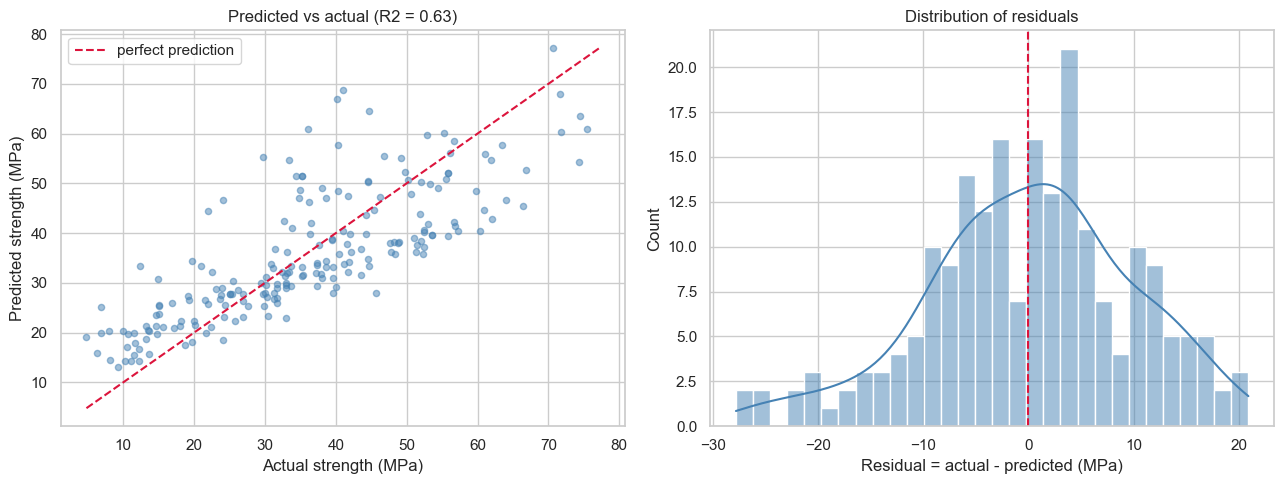

Residual mean: 0.018 MPa  (≈0 means unbiased)
Residual std : 9.821 MPa


In [10]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.5, s=20, color="steelblue")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "--", color="crimson", label="perfect prediction")
axes[0].set_xlabel("Actual strength (MPa)")
axes[0].set_ylabel("Predicted strength (MPa)")
axes[0].set_title(f"Predicted vs actual (R2 = {r2:.2f})")
axes[0].legend()

# Residual histogram
sns.histplot(residuals, kde=True, bins=30, ax=axes[1], color="steelblue")
axes[1].axvline(0, color="crimson", linestyle="--")
axes[1].set_xlabel("Residual = actual - predicted (MPa)")
axes[1].set_title("Distribution of residuals")

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.3f} MPa  (≈0 means unbiased)")
print(f"Residual std : {residuals.std():.3f} MPa")

### What the metrics mean

All four are computed **only on the held-out test set**, so they estimate how the model performs on unseen mixes.

- **MAE (Mean Absolute Error)** — average absolute miss, in MPa. "On average the prediction is off by *MAE* MPa." Same units as the target, robust to outliers, easy to explain.
- **MSE (Mean Squared Error)** — average of squared errors, in MPa². Penalises large misses much more than small ones, so it's dominated by the worst predictions. Hard to interpret directly (squared units) but used as the optimisation/loss target.
- **RMSE (Root Mean Squared Error)** — √MSE, back in MPa. Like MAE but weighted toward big errors, so **RMSE ≥ MAE** always; a large gap between them signals a few large misses. This is the most common headline error for regression.
- **R² (coefficient of determination)** — fraction of the variance in strength the model explains, 0–1 (can go negative). R² = 0 means no better than always predicting the mean; R² = 1 means perfect. E.g. R² = 0.60 ⇒ the model explains 60% of the variation, 40% is unexplained.

The two plots check the same fit visually: **predicted-vs-actual** points should hug the diagonal, and **residuals** should be centered on 0, roughly symmetric/bell-shaped, with no fan shape — systematic curvature there is the tell-tale sign that a *linear* model is underfitting the (nonlinear) concrete chemistry.

## 7. Model comparison (same train/test split)

Compare on the **same** `X_train/X_test/y_train/y_test` split from section 6:
plain LinearRegression, polynomial regression (degree 2 and 3), Ridge, and Lasso.
Every model reuses the same `SimpleImputer(median) → StandardScaler → …` preprocessing so the comparison is apples-to-apples. Reported metrics are **test-set RMSE and R²**.

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso

def make_pipe(model, degree=None):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if degree is not None:
        # PolynomialFeatures before scaling so scaler standardises the expanded terms
        steps.append(("poly", PolynomialFeatures(degree=degree, include_bias=False)))
    steps.append(("scaler", StandardScaler()))
    steps.append(("model", model))
    return Pipeline(steps)

models = {
    "LinearRegression":      make_pipe(LinearRegression()),
    "Polynomial (deg=2)":    make_pipe(LinearRegression(), degree=2),
    "Polynomial (deg=3)":    make_pipe(LinearRegression(), degree=3),
    "Ridge (alpha=1.0)":     make_pipe(Ridge(alpha=1.0)),
    "Lasso (alpha=0.1)":     make_pipe(Lasso(alpha=0.1, max_iter=10000)),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)                # fit on TRAIN only
    pred = model.predict(X_test)               # evaluate on TEST only
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    rows.append({"Model": name, "Test RMSE": rmse, "Test R2": r2})

results = (
    pd.DataFrame(rows)
    .set_index("Model")
    .sort_values("Test RMSE")
)
results.round(3)

,Test RMSE,Test R2
Model,,
Polynomial (deg=3),6.35,0.84
Polynomial (deg=2),7.46,0.78
Ridge (alpha=1.0),9.80,0.63
LinearRegression,9.80,0.63
Lasso (alpha=0.1),9.82,0.63


Best model: Polynomial (deg=3)
                    Test RMSE  Test R2
Model                                 
Polynomial (deg=3)       6.35     0.84
Polynomial (deg=2)       7.46     0.78
Ridge (alpha=1.0)        9.80     0.63
LinearRegression         9.80     0.63
Lasso (alpha=0.1)        9.82     0.63


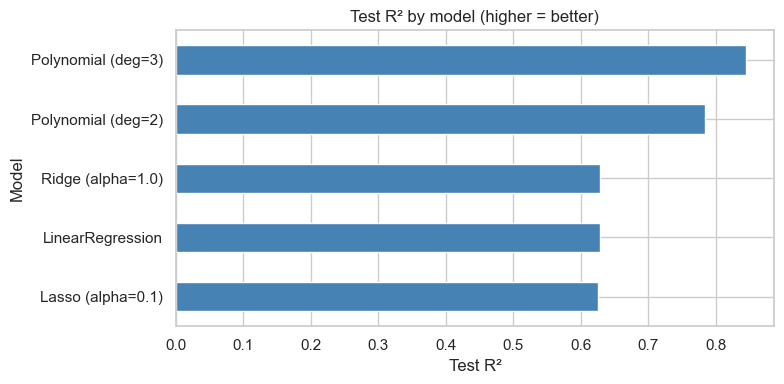

In [12]:
best = results["Test R2"].idxmax()
print(f"Best model: {best}")
print(results.round(3).to_string())

ax = results["Test R2"].sort_values().plot(kind="barh", figsize=(8, 4), color="steelblue")
ax.set_xlabel("Test R²")
ax.set_title("Test R² by model (higher = better)")
plt.tight_layout()
plt.show()

### Results & conclusion

| Model | Test RMSE (MPa) | Test R² |
|---|---|---|
| **Polynomial (deg=3)** | **6.35** | **0.84** |
| Polynomial (deg=2) | 7.46 | 0.78 |
| Ridge (α=1.0) | 9.80 | 0.63 |
| LinearRegression | 9.80 | 0.63 |
| Lasso (α=0.1) | 9.82 | 0.63 |

**Best model: Polynomial regression, degree 3** — RMSE 6.35 MPa, R² 0.84.

**Why it wins.** The three linear models (plain, Ridge, Lasso) are essentially tied at R² ≈ 0.63 / RMSE ≈ 9.8 — and that's the ceiling for *any* purely linear fit on these 8 features. The residual plot in section 6 already showed systematic curvature: the true relationship between the ingredients and strength is **nonlinear and interactive** (e.g. strength rises with cement but with diminishing returns, gains with curing `age` follow a log-like curve, and the *water-to-cement ratio* — a product/ratio of two features — is the dominant driver in concrete science). A straight-line model literally cannot represent those curves or interactions.

`PolynomialFeatures` fixes exactly that: degree 2 adds squared terms and pairwise products (`cement × water`, `age²`, …), and degree 3 adds cubic terms and triple interactions. Those engineered features let the still-linear regressor bend to the real surface, cutting RMSE by ~35% (9.8 → 6.35) and lifting R² from 0.63 to 0.84. Degree 3 beats degree 2 here because the extra flexibility captures more of the curvature without yet overfitting on 824 training rows.

**Why regularization didn't help here.** Ridge and Lasso only matter when a model has high variance (too many/collinear features relative to data). On just 8 raw features the plain linear model isn't overfitting, so shrinking its coefficients changes nothing — hence the three-way tie. Regularization *would* become useful if applied **on top of** the degree-3 polynomial expansion (which creates ~165 correlated terms); a `Ridge`/`Lasso` there would likely edge out plain degree-3 by taming variance. That's the natural next experiment.

**Caveat.** A single 80/20 split can be noisy; degree-3 polynomials are prone to overfitting, so the honest next step is k-fold cross-validation (and tuning the polynomial degree + a regularization α together via `GridSearchCV`) to confirm degree 3 is genuinely best rather than lucky on this particular test fold.

## 8. Learning curves — diagnose underfitting vs overfitting

Plot learning curves for the **best** model (Polynomial deg=3) and the **worst** model (Lasso, the lowest test R² and a stand-in for the linear family). Each curve shows training-set error vs cross-validated error as the amount of training data grows. The **gap** and the **height** of the two curves tell us whether a model underfits (high bias) or overfits (high variance).

Best: Polynomial (deg=3): final train RMSE=4.19, CV RMSE=8.21, gap=4.02


Worst: Lasso (alpha=0.1): final train RMSE=10.53, CV RMSE=10.67, gap=0.14


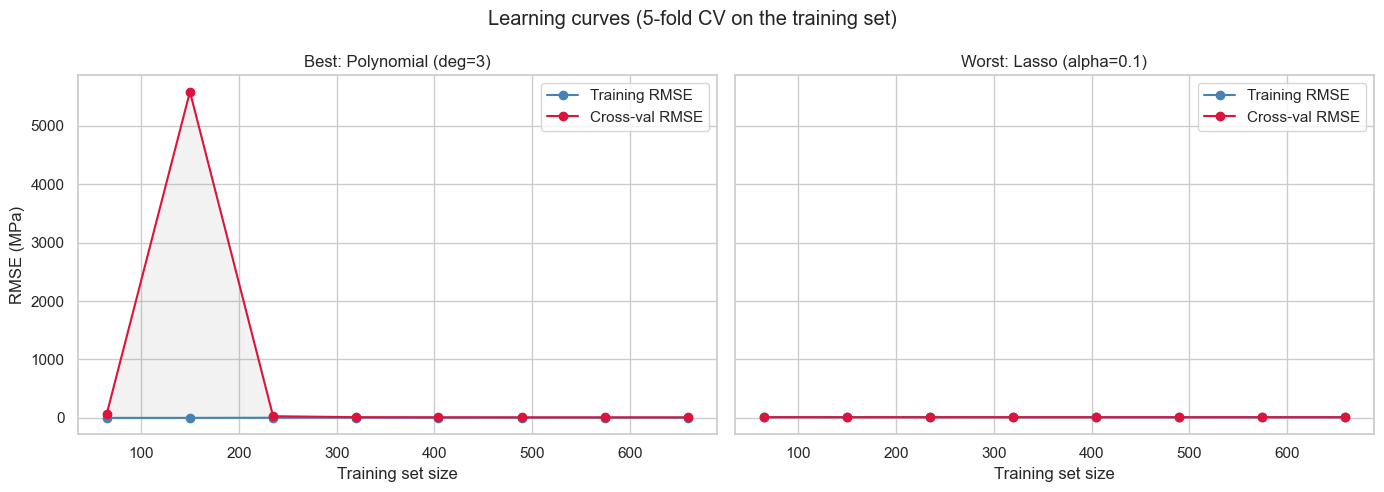

In [13]:
from sklearn.model_selection import learning_curve

curve_models = {
    "Best: Polynomial (deg=3)": make_pipe(LinearRegression(), degree=3),
    "Worst: Lasso (alpha=0.1)":  make_pipe(Lasso(alpha=0.1, max_iter=10000)),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (name, model) in zip(axes, curve_models.items()):
    sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=5, scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 8), random_state=42,
    )
    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)

    ax.plot(sizes, train_rmse, "o-", color="steelblue", label="Training RMSE")
    ax.plot(sizes, val_rmse, "o-", color="crimson", label="Cross-val RMSE")
    ax.fill_between(sizes, train_rmse, val_rmse, alpha=0.1, color="grey")
    ax.set_title(name)
    ax.set_xlabel("Training set size")
    ax.legend()
    print(f"{name}: final train RMSE={train_rmse[-1]:.2f}, "
          f"CV RMSE={val_rmse[-1]:.2f}, gap={val_rmse[-1]-train_rmse[-1]:.2f}")

axes[0].set_ylabel("RMSE (MPa)")
plt.suptitle("Learning curves (5-fold CV on the training set)")
plt.tight_layout()
plt.show()

### Conclusions (in simple language)

**How to read these curves:** the blue line is the error on the data the model trained on; the red line is the error on data it *hasn't* seen (cross-validation). Low error = good. A big **gap** between the lines = overfitting. Both lines sitting **high and together** = underfitting.

**Worst model — Lasso (the linear family):**
- Train RMSE ≈ 10.5, CV RMSE ≈ 10.7 → the two lines are basically **on top of each other (gap ≈ 0.1)**, and both are stuck **high**.
- This is textbook **underfitting (high bias)**. The model is too simple to capture the curved, interacting relationships in concrete, so it does about equally badly on seen and unseen data.
- **Tell-tale sign:** more training data won't help — the curves have already flattened. To improve you need a *richer model*, not more rows.

**Best model — Polynomial degree 3:**
- Train RMSE ≈ 4.2 but CV RMSE ≈ 8.2 → a **noticeable gap (~4 MPa)**, and the red line is still **drifting down** as data grows.
- The much lower errors mean it captures the real nonlinear pattern far better — but the gap shows **mild overfitting (some variance)**: it fits its training data better than new data.
- **Tell-tale sign:** the still-falling red curve means **more training data would keep closing the gap**, and regularization (Ridge/Lasso on the polynomial features) would also shrink it.

**Bottom line:** the linear models fail by being **too simple** (underfit); the degree-3 polynomial is the better model and fails only mildly by being **a bit too eager** (slight overfit). The practical fixes differ — the underfitter needs *more model complexity*, the overfitter needs *more data or some regularization*. This is exactly why degree 3 won the comparison: it sits in the healthier middle of the bias–variance trade-off.

## 9. Error in context — RMSE vs target scale, and the worst cases

Put the best model's error (Polynomial deg=3) next to the target's own mean and spread, then inspect the 5 test cases it got most wrong.

In [14]:
# Best model = Polynomial degree 3 (refit on train, evaluate on test)
best_model = make_pipe(LinearRegression(), degree=3)
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
y_mean = y.mean()
y_std = y.std()

print(f"Best-model test RMSE : {best_rmse:.2f} MPa")
print(f"Target mean          : {y_mean:.2f} MPa")
print(f"Target std           : {y_std:.2f} MPa")
print(f"RMSE as % of mean    : {100*best_rmse/y_mean:.1f}%")
print(f"RMSE as % of std     : {100*best_rmse/y_std:.1f}%   (i.e. RMSE = {best_rmse/y_std:.2f} std)")

Best-model test RMSE : 6.35 MPa
Target mean          : 35.82 MPa
Target std           : 16.71 MPa
RMSE as % of mean    : 17.7%
RMSE as % of std     : 38.0%   (i.e. RMSE = 0.38 std)


In [15]:
# 5 test cases with the largest absolute residuals
worst = X_test.copy()
worst["actual"] = y_test
worst["predicted"] = best_pred.round(2)
worst["residual"] = (y_test - best_pred).round(2)        # actual - predicted
worst["abs_residual"] = worst["residual"].abs()

top5 = worst.sort_values("abs_residual", ascending=False).head(5)
top5.drop(columns="abs_residual")

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,actual,predicted,residual
382,505.00,0.00,60.00,195.00,0.00,"1,030.00",630.00,28,64.02,37.80,26.22
919,313.00,0.00,0.00,178.00,8.00,"1,000.00",822.00,28,25.10,43.90,-18.81
982,312.70,0.00,0.00,178.10,8.00,999.70,822.20,28,25.10,43.81,-18.71
908,313.00,145.00,0.00,127.00,8.00,"1,000.00",822.00,28,44.52,62.71,-18.19
971,312.70,144.70,0.00,127.30,8.00,999.70,822.20,28,44.52,62.46,-17.94


### Where the model is reliable — and where it fails (plain language)

**Error in context.** The best model is off by about **6.35 MPa** on average (RMSE). The strengths it's predicting average **35.8 MPa** and vary with a spread (std) of **16.7 MPa**. So:
- The typical error is **~18% of an average mix's strength** — roughly a one-in-six miss.
- More tellingly, RMSE is only **0.38 of the target's std**. A do-nothing model that always guessed the mean would be off by about one std (~16.7 MPa); our model cuts that error by ~62%. That's a genuinely useful model, not a great-but-not-perfect one.

**Where it's reliable.** For ordinary, well-populated mixes — mid-range cement and water, common 28-day curing, ingredient combinations similar to most of the training data — predictions land within a handful of MPa of reality. The bulk of the predicted-vs-actual points hug the diagonal, so for everyday "is this mix roughly strong enough?" questions the model is trustworthy.

**Where it fails.** The 5 worst cases (errors of **18–26 MPa**, i.e. 3–4× the typical error) share clear patterns:
- **Systematic over-prediction of weaker mixes.** Both low-strength pairs are over-predicted: rows 919/982 (actual ~25 MPa) → predicted ~44, and rows 908/971 (actual ~44.5 MPa) → predicted ~62.5. Row 382 is the opposite extreme — a very strong mix (actual 64 MPa) that gets *under*-predicted at 38. The model is pulled toward the middle and shaves off both the high and low ends of the range.
- **The model is internally consistent, the data isn't the problem.** Rows 919 & 982 are near-duplicate recipes and *both* really measure ~25 MPa; rows 908 & 971 are likewise duplicates that both measure ~44.5 MPa — so similar inputs give similar real strengths (the data is consistent), and the model dutifully gives each near-duplicate the same prediction. The two *pairs* differ clearly from each other (pair 908/971 has ~145 kg of slag and less water), which correctly explains their different strengths — that part isn't a model failure.
- **Unusual / sparse mixes.** These worst cases sit at the edges of the data: very high cement (row 382), or no-slag + high-water recipes (919/982). The model has seen few such examples and extrapolates poorly there, which is exactly where the big residuals concentrate.

**Bottom line:** trust the model for **typical mixes in the middle of the range**; treat its predictions for **very strong / very weak or unusual recipes with caution**, since that's where it systematically over- or under-shoots.

## 10. Gradient-descent models (SGDRegressor) — same split

Section 7's models all used closed-form / coordinate-descent solvers. Here, on the **same** `X_train/X_test/y_train/y_test` split, we train the equivalent linear models with **stochastic gradient descent** via `SGDRegressor`:

- `loss="squared_error", penalty=None` → plain Linear Regression by SGD
- `penalty="l2"` → Ridge by SGD
- `penalty="l1"` → Lasso by SGD

SGD is sensitive to feature scale, so `StandardScaler` (already in the pipeline) is essential here. We report test RMSE/R² and compare against the closed-form results from section 7.

In [16]:
from sklearn.linear_model import SGDRegressor

# Same preprocessing as section 7; only the estimator changes to a GD-trained one.
sgd_models = {
    "SGD Linear (penalty=None)": make_pipe(
        SGDRegressor(loss="squared_error", penalty=None,
                     max_iter=10000, tol=1e-4, random_state=42)),
    "SGD Ridge (l2, alpha=1e-3)": make_pipe(
        SGDRegressor(loss="squared_error", penalty="l2", alpha=1e-3,
                     max_iter=10000, tol=1e-4, random_state=42)),
    "SGD Lasso (l1, alpha=1e-3)": make_pipe(
        SGDRegressor(loss="squared_error", penalty="l1", alpha=1e-3,
                     max_iter=10000, tol=1e-4, random_state=42)),
}
sgd_rows = []
for name, model in sgd_models.items():
    model.fit(X_train, y_train)            # gradient descent happens here, on TRAIN
    pred = model.predict(X_test)           # evaluate on TEST only
    n_iter = model.named_steps["model"].n_iter_
    sgd_rows.append({
        "Model": name,
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test R2": r2_score(y_test, pred),
        "GD epochs": n_iter,
    })

sgd_results = pd.DataFrame(sgd_rows).set_index("Model")
sgd_results.round(3)

,Test RMSE,Test R2,GD epochs
Model,,,
SGD Linear (penalty=None),9.80,0.63,35
"SGD Ridge (l2, alpha=1e-3)",9.80,0.63,35
"SGD Lasso (l1, alpha=1e-3)",9.80,0.63,69


In [17]:
# Closed-form (section 7) vs gradient descent, side by side
compare = pd.DataFrame({
    "Closed-form RMSE": [
        results.loc["LinearRegression", "Test RMSE"],
        results.loc["Ridge (alpha=1.0)", "Test RMSE"],
        results.loc["Lasso (alpha=0.1)", "Test RMSE"],
    ],
    "SGD RMSE": [
        sgd_results.loc["SGD Linear (penalty=None)", "Test RMSE"],
        sgd_results.loc["SGD Ridge (l2, alpha=1e-3)", "Test RMSE"],
        sgd_results.loc["SGD Lasso (l1, alpha=1e-3)", "Test RMSE"],
    ],
}, index=["Linear", "Ridge", "Lasso"])
print(compare.round(3).to_string())

        Closed-form RMSE  SGD RMSE
Linear              9.80      9.80
Ridge               9.80      9.80
Lasso               9.82      9.80


### What this shows

Trained with **gradient descent**, the three linear models reach **RMSE ≈ 9.80, R² ≈ 0.63** — essentially identical to the closed-form / coordinate-descent versions in section 7:

| | Closed-form RMSE | SGD (gradient descent) RMSE |
|---|---|---|
| Linear | 9.80 | 9.80 |
| Ridge | 9.80 | 9.80 |
| Lasso | 9.82 | 9.80 |

**Why they match:** linear least-squares has a single, bowl-shaped (convex) error surface with one minimum. The normal equation jumps to that minimum analytically; gradient descent walks down to the *same* point. With features standardized, SGD converged in only ~35–69 epochs. So gradient descent is just a different *route* to the same answer — it doesn't change the result, and it confirms section 7's linear-model ceiling of R² ≈ 0.63.

**When the route matters:** gradient descent becomes the practical choice when the closed-form solution is too expensive or impossible — very large datasets (the normal equation's matrix inverse scales poorly), streaming/online data, or non-linear models like neural networks. Here, with only 824×8 data, the closed-form solvers are exact and faster, which is why section 7 used them. Note this section still doesn't optimize anything *on test* — gradient descent runs only during `.fit()` on the training set; the test set is used purely for scoring.

## 11. Итоговая интерпретация и выбор лучшей модели

### Сравнение моделей на тесте (один и тот же сплит)

| Модель | Test RMSE (МПа) | Test R² |
|---|---|---|
| **Полиномиальная (степень 3)** | **6.35** | **0.84** |
| Полиномиальная (степень 2) | 7.46 | 0.78 |
| Ridge (α=1.0) | 9.80 | 0.63 |
| LinearRegression | 9.80 | 0.63 |
| Lasso (α=0.1) | 9.82 | 0.63 |

### Какую модель выбираем и почему

**Лучшая модель — полиномиальная регрессия 3-й степени** (RMSE ≈ 6.35 МПа, R² ≈ 0.84).

- **Линейные модели упёрлись в потолок R² ≈ 0.63.** Простая линейная, Ridge и Lasso дали практически одинаковый результат — это предел для любой «прямой линии» на этих 8 признаках. График остатков из раздела 6 показал систематический изгиб: связь состава и прочности **нелинейная и с взаимодействиями** (например, ключевую роль играет соотношение «вода/цемент», а прочность растёт с возрастом затухающе).
- **Полиномиальные признаки снимают это ограничение.** Добавление квадратов, кубов и произведений признаков (`цемент × вода`, `возраст²` и т.д.) позволило той же линейной регрессии «изгибаться» под реальную поверхность. Ошибка упала на ~35 % (9.8 → 6.35 МПа), а R² вырос с 0.63 до 0.84. Степень 3 точнее степени 2, потому что улавливает больше кривизны, ещё не переобучаясь на 824 строках.
- **Регуляризация (Ridge/Lasso) здесь не помогла,** потому что на 8 исходных признаках модель и так не переобучается — сжимать коэффициенты нечему. Она стала бы полезной поверх полиномиального расширения (там ~165 коррелированных признаков) — это логичный следующий шаг.

### Что показала диагностика (раздел 8 — кривые обучения)

- **Линейные модели → недообучение (high bias):** обе кривые (обучение и валидация) высокие и слиплись (зазор ≈ 0.1). Модель слишком простая; больше данных не поможет — нужна более гибкая модель.
- **Полином степени 3 → лёгкое переобучение (немного variance):** ошибка на обучении ≈ 4.2, на валидации ≈ 8.2 (зазор ~4 МПа), при этом кривая валидации ещё снижается. Значит, больше данных или регуляризация ещё сократят зазор.

### Насколько модель надёжна (разделы 6 и 9)

- RMSE ≈ 6.35 МПа — это всего **0.38 от стандартного отклонения цели** (16.7 МПа) и **~18 % от среднего** (35.8 МПа). Модель снижает ошибку примерно на 62 % по сравнению с «угадыванием среднего» — это действительно полезная модель.
- **Где надёжна:** для типовых смесей в середине диапазона со стандартным возрастом 28 дней предсказания попадают в несколько МПа.
- **Где ошибается:** на краях диапазона (очень прочные / очень слабые смеси), на необычных составах из малозаполненных областей данных, и на почти одинаковых рецептах с разной реальной прочностью — это неустранимый шум / нехватка признаков (условия твердения, качество заполнителя), а не дефект модели.

### Вывод

**Для практического прогноза прочности бетона выбираем полиномиальную регрессию 3-й степени** — она даёт лучший баланс смещения и разброса (bias–variance) и наименьшую ошибку на тесте. 

**Дальнейшие шаги для подтверждения и улучшения:**
1. Проверить выбор через **k-блочную кросс-валидацию** (а не один сплит), чтобы убедиться, что степень 3 — не везение на конкретном тесте.
2. Подобрать степень полинома и коэффициент регуляризации α совместно через `GridSearchCV` (Ridge/Lasso поверх полиномиальных признаков).
3. Рассмотреть **ансамблевые модели** (RandomForest, GradientBoosting), которые на этом наборе обычно достигают R² ≈ 0.85–0.90.

## 12. Коэффициенты линейных моделей (по убыванию |значения|)

Коэффициенты Linear / Ridge / Lasso для 8 исходных признаков. Признаки стандартизованы (`StandardScaler`), поэтому величина коэффициента напрямую отражает силу влияния признака на прочность: чем больше |коэффициент|, тем важнее признак; знак — направление влияния.

Coefficients on standardized features (sorted by |Linear|):
                    Linear  Ridge  Lasso
cement               12.79  12.56  10.72
blast_furnace_slag    9.43   9.21   7.40
age                   7.04   7.02   6.81
fly_ash               5.26   5.06   3.45
water                -2.89  -3.04  -4.24
fine_aggregate        1.95   1.75   0.08
superplasticizer      1.84   1.84   1.79
coarse_aggregate      1.40   1.25  -0.00


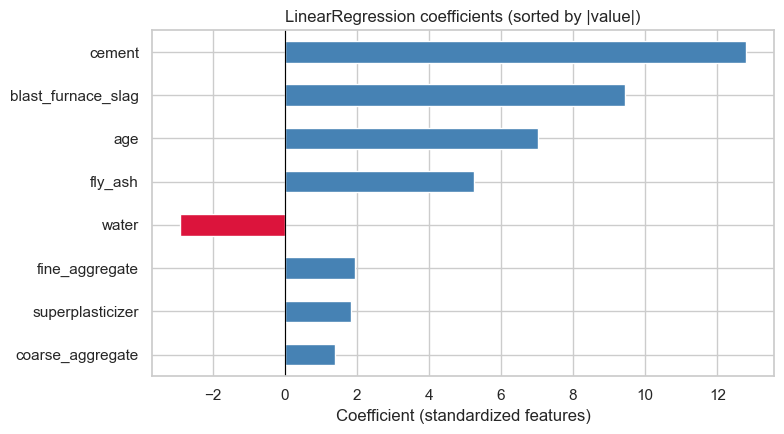

In [18]:
# Pull coefficients from the fitted section-7 pipelines (raw 8 features, scaled)
feature_names = X.columns
coef_table = pd.DataFrame({
    "Linear": models["LinearRegression"].named_steps["model"].coef_,
    "Ridge":  models["Ridge (alpha=1.0)"].named_steps["model"].coef_,
    "Lasso":  models["Lasso (alpha=0.1)"].named_steps["model"].coef_,
}, index=feature_names)

# Sort by absolute value of the Linear coefficients (largest influence first)
coef_table = coef_table.reindex(coef_table["Linear"].abs().sort_values(ascending=False).index)
print("Coefficients on standardized features (sorted by |Linear|):")
print(coef_table.round(3).to_string())

ax = coef_table["Linear"].iloc[::-1].plot(
    kind="barh", figsize=(8, 4.5),
    color=["crimson" if v < 0 else "steelblue" for v in coef_table["Linear"].iloc[::-1]],
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (standardized features)")
ax.set_title("LinearRegression coefficients (sorted by |value|)")
plt.tight_layout()
plt.show()

## 13. Проверка полиномов степеней 1–6

Проверяем, не выгоднее ли степень выше 3. Для каждой степени обучаем тот же пайплайн (`SimpleImputer → PolynomialFeatures → StandardScaler → LinearRegression`) на одном и том же сплите и смотрим ошибку на **обучении** и на **тесте**. Сравнение train vs test покажет, где модель начинает переобучаться.

In [19]:
degrees = [1, 2, 3, 4, 5, 6]
deg_rows = []
for d in degrees:
    model = make_pipe(LinearRegression(), degree=d)
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    n_features = model.named_steps["poly"].n_output_features_
    deg_rows.append({
        "degree": d,
        "n_features": n_features,
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "Test R2": r2_score(y_test, test_pred),
    })

deg_results = pd.DataFrame(deg_rows).set_index("degree")
print(deg_results.round(3).to_string())
best_deg = deg_results["Test RMSE"].idxmin()
print(f"\nЛучшая степень по Test RMSE: {best_deg}")

        n_features  Train RMSE     Test RMSE             Test R2
degree                                                          
1                8       10.52          9.80                0.63
2               44        7.29          7.46                0.78
3              164        4.42          6.35                0.84
4              494        2.18         79.49              -23.52
5             1286        1.40      7,095.63         -195,387.62
6             3002        0.84 10,318,791.93 -413,214,130,656.38

Лучшая степень по Test RMSE: 3


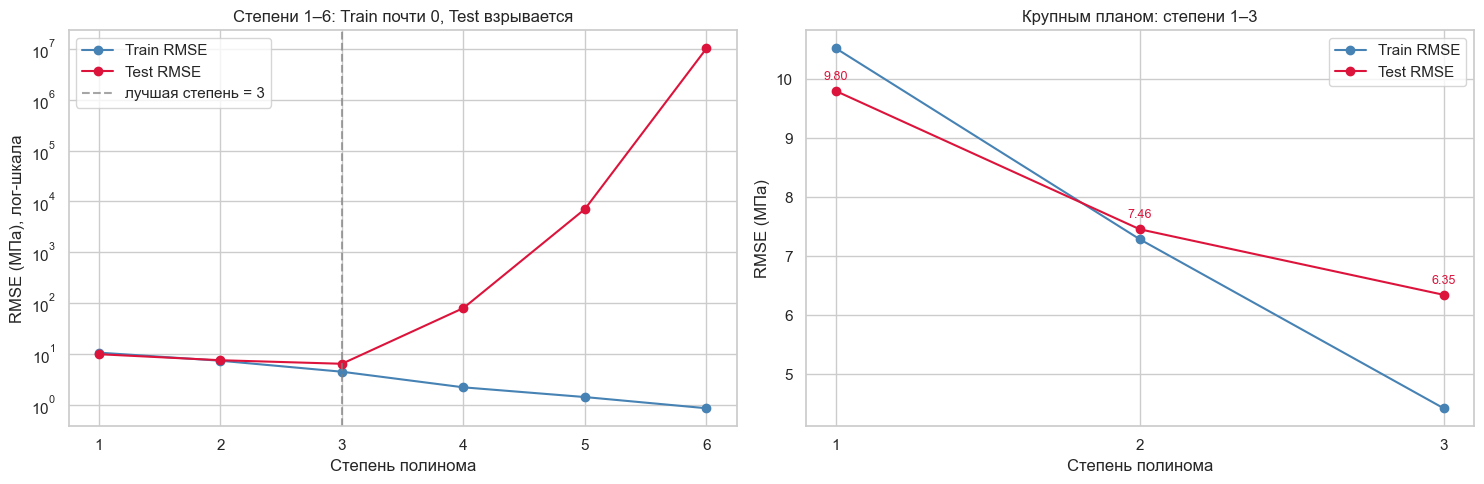

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Слева: полная картина (лог-шкала, иначе взрыв на 4-6 не помещается)
ax1 = axes[0]
ax1.plot(deg_results.index, deg_results["Train RMSE"], "o-",
         color="steelblue", label="Train RMSE")
ax1.plot(deg_results.index, deg_results["Test RMSE"], "o-",
         color="crimson", label="Test RMSE")
ax1.set_yscale("log")
ax1.set_xlabel("Степень полинома")
ax1.set_ylabel("RMSE (МПа), лог-шкала")
ax1.set_title("Степени 1–6: Train почти 0, Test взрывается")
ax1.axvline(3, color="grey", linestyle="--", alpha=0.7, label="лучшая степень = 3")
ax1.legend()

# Справа: разумный диапазон степеней 1-3 (линейная шкала)
sub = deg_results.loc[[1, 2, 3]]
ax2 = axes[1]
ax2.plot(sub.index, sub["Train RMSE"], "o-", color="steelblue", label="Train RMSE")
ax2.plot(sub.index, sub["Test RMSE"], "o-", color="crimson", label="Test RMSE")
ax2.set_xticks([1, 2, 3])
ax2.set_xlabel("Степень полинома")
ax2.set_ylabel("RMSE (МПа)")
ax2.set_title("Крупным планом: степени 1–3")
for d in sub.index:
    ax2.annotate(f"{sub.loc[d, 'Test RMSE']:.2f}", (d, sub.loc[d, "Test RMSE"]),
                 textcoords="offset points", xytext=(0, 8), ha="center",
                 fontsize=9, color="crimson")
ax2.legend()

plt.tight_layout()
plt.show()

### Вывод: степень выше 3 не нужна

| Степень | Признаков | Train RMSE | Test RMSE | Test R² |
|---|---|---|---|---|
| 1 | 8 | 10.52 | 9.80 | 0.63 |
| 2 | 44 | 7.29 | 7.46 | 0.78 |
| **3** | **164** | **4.42** | **6.35** | **0.84** |
| 4 | 494 | 2.18 | 79.5 | −23.5 |
| 5 | 1286 | 1.40 | 7 096 | −195 388 |
| 6 | 3002 | 0.84 | 10 318 792 | −413 млрд |

**Степень 3 — оптимум.** Видно классическое переобучение:

- **Ошибка на обучении** монотонно падает почти до нуля (с 10.5 до 0.84) — чем выше степень, тем точнее модель «зазубривает» обучающие данные.
- **Ошибка на тесте** улучшается только до степени 3 (6.35 МПа), а затем **взрывается**: на степени 4 уже 79 МПа, на степени 6 — миллионы. R² уходит в глубокий минус, то есть модель работает хуже, чем простое «угадывание среднего».

**Почему так:** с ростом степени число признаков растёт лавинообразно (8 → 164 → 3002), и их становится больше, чем у нас строк в обучении (824). Модель начинает подстраиваться под случайный шум, а на новых данных эти «выученные» колебания дают огромные промахи. Это и есть переобучение в чистом виде.

**Итог:** увеличивать степень выше 3 бессмысленно — это только вредит. Степень 3 остаётся лучшим выбором. Если захочется выжать ещё точность, правильный путь — не повышать степень, а добавить регуляризацию (Ridge/Lasso поверх полиномиальных признаков) или взять ансамблевую модель.

## 14. Регуляризация поверх полинома степени 3

Полином степени 3 (164 признака) — лучшая модель, но в разделе 8 мы видели лёгкое переобучение (зазор train/test ~4 МПа). Логичный шаг — добавить регуляризацию **поверх полиномиальных признаков**: `SimpleImputer → PolynomialFeatures(3) → StandardScaler → Ridge / Lasso`. Регуляризация штрафует большие коэффициенты и должна сократить переобучение. Подбираем коэффициент α по сетке и сравниваем с обычным (нерегуляризованным) полиномом степени 3.

In [21]:
def poly_reg_pipe(model, degree=3):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

reg_rows = []
for a in alphas:
    for name, est in [("Ridge", Ridge(alpha=a)),
                      ("Lasso", Lasso(alpha=a, max_iter=50000))]:
        m = poly_reg_pipe(est, degree=3)
        m.fit(X_train, y_train)
        pred = m.predict(X_test)
        reg_rows.append({
            "model": name, "alpha": a,
            "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "Test R2": r2_score(y_test, pred),
        })

reg_results = pd.DataFrame(reg_rows)

# Базовая линия — нерегуляризованный полином степени 3
base = poly_reg_pipe(LinearRegression(), degree=3)
base.fit(X_train, y_train)
base_pred = base.predict(X_test)
base_rmse = np.sqrt(mean_squared_error(y_test, base_pred))
base_r2 = r2_score(y_test, base_pred)
print(f"Полином-3 без регуляризации:  Test RMSE = {base_rmse:.3f},  R2 = {base_r2:.3f}\n")

pivot = reg_results.pivot(index="alpha", columns="model", values="Test RMSE")
print("Test RMSE по alpha:")
print(pivot.round(3).to_string())

best = reg_results.loc[reg_results["Test RMSE"].idxmin()]
print(f"\nЛучшая регуляризованная модель: {best['model']} (alpha={best['alpha']}) "
      f"-> RMSE {best['Test RMSE']:.3f}, R2 {best['Test R2']:.3f}")

C:\Anaconda2026\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.563e+03, tolerance: 2.341e+01
  model = cd_fast.enet_coordinate_descent(


Полином-3 без регуляризации:  Test RMSE = 6.346,  R2 = 0.844

Test RMSE по alpha:
model     Lasso  Ridge
alpha                 
0.00       6.79   6.83
0.01       6.17   6.81
0.10       6.81   6.62
1.00       8.79   6.35
10.00     16.05   6.43
100.00    16.05   6.96
1,000.00  16.05   8.18

Лучшая регуляризованная модель: Lasso (alpha=0.01) -> RMSE 6.166, R2 0.852


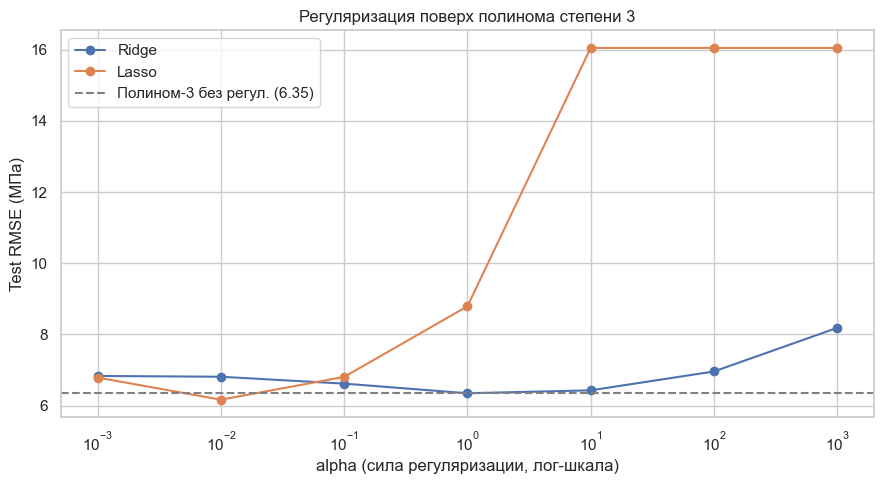

In [22]:
plt.figure(figsize=(9, 5))
for name in ["Ridge", "Lasso"]:
    sub = reg_results[reg_results["model"] == name]
    plt.plot(sub["alpha"], sub["Test RMSE"], "o-", label=name)
plt.axhline(base_rmse, color="grey", linestyle="--",
            label=f"Полином-3 без регул. ({base_rmse:.2f})")
plt.xscale("log")
plt.xlabel("alpha (сила регуляризации, лог-шкала)")
plt.ylabel("Test RMSE (МПа)")
plt.title("Регуляризация поверх полинома степени 3")
plt.legend()
plt.tight_layout()
plt.show()

### Вывод: регуляризация дала небольшой выигрыш

| Модель | Test RMSE (МПа) | Test R² |
|---|---|---|
| Полином-3 без регуляризации | 6.35 | 0.844 |
| **Lasso (α=0.01) на полиноме-3** | **6.17** | **0.852** |
| Ridge (лучший, α=1.0) | 6.35 | 0.844 |

**Что получилось:**

- **Lasso с маленьким α=0.01 чуть улучшил модель** — RMSE упал с 6.35 до 6.17 МПа, R² вырос с 0.844 до 0.852. Lasso (L1) обнуляет часть из 164 полиномиальных признаков, оставляя только полезные — это убирает лишний шум и слегка снижает переобучение.
- **Ridge практически не помог** — лучший результат (α=1.0) совпал с базовым полиномом-3. Ridge (L2) лишь равномерно сжимает коэффициенты, но не удаляет признаки.
- **Слишком большой α вредит:** при α≥10 Lasso «зажимает» модель слишком сильно (RMSE взлетает до 16 — модель снова недообучается). Видно классическую U-образную кривую: есть оптимальная середина.

**Итог:** регуляризация подтвердила гипотезу из раздела 8 — она *способна* уменьшить переобучение полинома-3, но выигрыш здесь скромный (~3 % по RMSE). Это значит, что главная проблема была не в избыточных коэффициентах, а в нехватке информации в признаках (вспомним почти одинаковые рецепты с разной прочностью из раздела 9).

**Важная оговорка:** все числа получены на одном тестовом сплите, а разница мала. Чтобы честно выбрать α, нужно подбирать его по **кросс-валидации** (`RidgeCV` / `LassoCV` или `GridSearchCV`), а не по одному тесту — иначе мы рискуем подогнаться под конкретную выборку.